In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix,classification_report

In [17]:
df = pd.read_csv(r"G:\My Drive\Credit Card Anomaly Detection\data\raw\creditcard.csv")

separate X and y

In [19]:
X = df.drop(columns='Class')
y = df['Class']

In [20]:
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


Train test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scale the features

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Logistic Regression baseline

In [24]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Prediction

In [25]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [27]:
y_prob

array([0.00569098, 0.06755242, 0.00011903, ..., 0.00026008, 0.00375493,
       0.08229136], shape=(56962,))

Evaluation

In [29]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("PR-AUC:", pr_auc)

Precision: 0.06097560975609756
Recall: 0.9183673469387755
F1-score: 0.11435832274459974
PR-AUC: 0.7189705771419241


In [30]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [31]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55478  1386]
 [    8    90]]


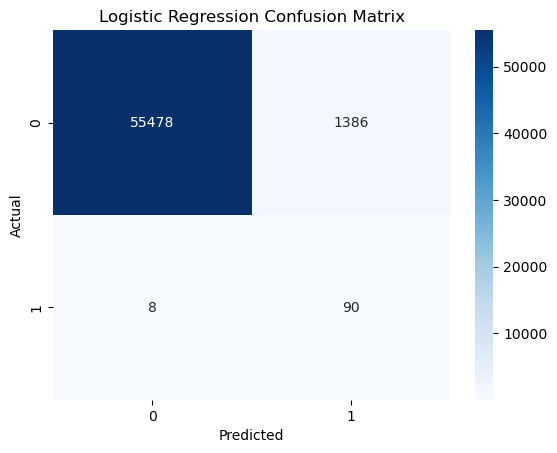

In [32]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Baseline resuts

In [33]:
baseline_results = {
    "Model": "Logistic Regression",
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "PR-AUC": pr_auc
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Precision': 0.06097560975609756, 'Recall': 0.9183673469387755, 'F1': 0.11435832274459974, 'PR-AUC': 0.7189705771419241}
